In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix,classification_report,roc_curve,auc,accuracy_score,roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
df = pd.read_csv("hospital_appointments.csv")

df = df.drop(columns=["Unnamed: 0"], errors="ignore")

df.to_csv("hospital_appointments.csv", index=False)

print(df.columns.tolist())

['PatientId', 'AppointmentID', 'Gender', 'ScheduledDay', 'AppointmentDay', 'Age', 'Neighbourhood', 'Scholarship', 'Hypertension', 'Diabetes', 'Alcoholism', 'Handicap', 'SMS_received', 'WaitingDays', 'AppointmentDayOfWeek', 'ScheduledDayOfWeek', 'ScheduledHour', 'AppointmentMonth', 'AppointmentDayOfMonth', 'PreviousAppointments', 'PreviousNoShows', 'PreviousShows', 'PreviousNoShowRate', 'SameDayAppointment', 'No_show']


In [2]:
# DATA CLEANING
# Checking for duplicate and null rows
print (df.isnull().sum())
print("duplicated rows: " ,df.duplicated().sum())

PatientId                0
AppointmentID            0
Gender                   0
ScheduledDay             0
AppointmentDay           0
Age                      0
Neighbourhood            0
Scholarship              0
Hypertension             0
Diabetes                 0
Alcoholism               0
Handicap                 0
SMS_received             0
WaitingDays              0
AppointmentDayOfWeek     0
ScheduledDayOfWeek       0
ScheduledHour            0
AppointmentMonth         0
AppointmentDayOfMonth    0
PreviousAppointments     0
PreviousNoShows          0
PreviousShows            0
PreviousNoShowRate       0
SameDayAppointment       0
No_show                  0
dtype: int64
duplicated rows:  0


In [3]:
df["ScheduledDay"] = pd.to_datetime(df["ScheduledDay"])
df["AppointmentDay"] = pd.to_datetime(df["AppointmentDay"])
# FEATURE ENGINEERING
df["WaitingDays"] = (
    df["AppointmentDay"].dt.normalize()
    - df["ScheduledDay"].dt.normalize()
).dt.days
df["AppointmentDayOfWeek"] = df["AppointmentDay"].dt.dayofweek
df["ScheduledDayOfWeek"] = df["ScheduledDay"].dt.dayofweek
df["ScheduledHour"] = df["ScheduledDay"].dt.hour
df["AppointmentMonth"] = df["AppointmentDay"].dt.month
df["AppointmentDayOfMonth"] = df["AppointmentDay"].dt.day
df = df[[col for col in df.columns if col != "No_show"] + ["No_show"]]
df.to_csv("hospital_appointments.csv", index=False)
print (df.head())

      PatientId  AppointmentID  Gender              ScheduledDay  \
0   39217.84439        5751990       1 2016-05-31 10:56:41+00:00   
1   43741.75652        5760144       0 2016-06-01 14:22:58+00:00   
2   93779.52927        5712759       1 2016-05-18 09:12:29+00:00   
3  141724.16655        5637648       0 2016-04-29 07:13:36+00:00   
4  537615.28476        5637728       1 2016-04-29 07:19:57+00:00   

             AppointmentDay  Age   Neighbourhood  Scholarship  Hypertension  \
0 2016-06-03 00:00:00+00:00   44    PRAIA DO SUÁ            0             0   
1 2016-06-01 00:00:00+00:00   39     MARIA ORTIZ            0             0   
2 2016-05-18 00:00:00+00:00   33          CENTRO            0             0   
3 2016-05-02 00:00:00+00:00   12  FORTE SÃO JOÃO            0             0   
4 2016-05-06 00:00:00+00:00   14  FORTE SÃO JOÃO            0             0   

   Diabetes  ...  ScheduledDayOfWeek  ScheduledHour  AppointmentMonth  \
0         0  ...                   1       

In [ ]:
df = df.rename(columns={
        'Hipertension': 'Hypertension',
        'No-show': 'No_show',
        'Handcap': 'Handicap'
    })
df["No_show"] = df["No_show"].map({
    "No": 0, #attended
    "Yes": 1 #did not attend
})
df["Gender"] = df["Gender"].map({
    "M": 0,
    "F": 1
})
# Check
print(df["No_show"].value_counts())
print(df["No_show"].unique())
df.to_csv("hospital_appointments.csv", index=False)

No_show
0    88207
1    22314
Name: count, dtype: int64
[0 1]


No_show distribution: 20.19% no-shows, 79.81% shows


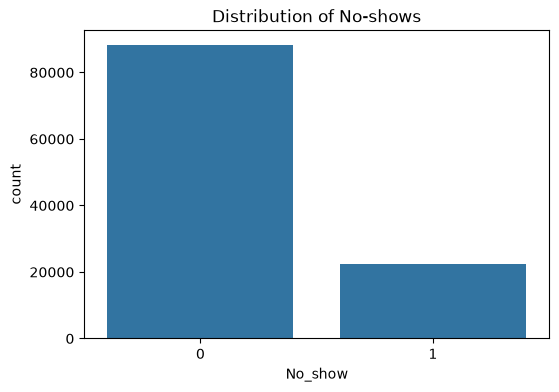

In [5]:
# Check target variable distribution
no_show_counts = df['No_show'].value_counts(normalize=True) * 100
print(f"No_show distribution: {no_show_counts[1]:.2f}% no-shows, {no_show_counts[0]:.2f}% shows")
plt.figure(figsize=(6, 4))
sns.countplot(x='No_show', data=df)
plt.title('Distribution of No-shows')
plt.show()

In [6]:
# Finding number of previous appointments and previous no-shows for each patient
df = df.sort_values(["PatientId", "AppointmentDay"])
df["PreviousAppointments"] = (
    df.groupby("PatientId").cumcount()
)

df["PreviousNoShows"] = (
    df.groupby("PatientId")["No_show"]
      .transform(lambda x: x.shift(1).fillna(0).cumsum())
)

# Number of previous appointments the patient attended
df["PreviousShows"] = (
    df["PreviousAppointments"] - df["PreviousNoShows"]
)

df["PreviousNoShowRate"] = (
    df["PreviousNoShows"] / df["PreviousAppointments"]
).fillna(0)

df["SameDayAppointment"] = (df["WaitingDays"] == 0).astype(int)
print(
    df[
        [
            "PatientId",
            "AppointmentDay",
            "No_show",
            "PreviousAppointments",
            "PreviousNoShows",
            "PreviousShows",
            "PreviousNoShowRate"
        ]
    ].head(20)
)
df = df[[col for col in df.columns if col != "No_show"] + ["No_show"]]
df.to_csv("hospital_appointments.csv", index=False)

       PatientId            AppointmentDay  No_show  PreviousAppointments  \
0   3.921784e+04 2016-06-03 00:00:00+00:00        0                     0   
1   4.374176e+04 2016-06-01 00:00:00+00:00        0                     0   
2   9.377953e+04 2016-05-18 00:00:00+00:00        0                     0   
3   1.417242e+05 2016-05-02 00:00:00+00:00        0                     0   
4   5.376153e+05 2016-05-06 00:00:00+00:00        0                     0   
5   5.628261e+06 2016-05-13 00:00:00+00:00        1                     0   
6   1.183186e+07 2016-05-19 00:00:00+00:00        0                     0   
7   2.263866e+07 2016-05-03 00:00:00+00:00        0                     0   
8   2.263866e+07 2016-06-08 00:00:00+00:00        0                     1   
9   5.216894e+07 2016-05-16 00:00:00+00:00        0                     0   
10  5.216894e+07 2016-05-17 00:00:00+00:00        0                     1   
11  5.422400e+07 2016-05-11 00:00:00+00:00        0                     0   

In [7]:
print (df.columns)

Index(['PatientId', 'AppointmentID', 'Gender', 'ScheduledDay',
       'AppointmentDay', 'Age', 'Neighbourhood', 'Scholarship', 'Hypertension',
       'Diabetes', 'Alcoholism', 'Handicap', 'SMS_received', 'WaitingDays',
       'AppointmentDayOfWeek', 'ScheduledDayOfWeek', 'ScheduledHour',
       'AppointmentMonth', 'AppointmentDayOfMonth', 'PreviousAppointments',
       'PreviousNoShows', 'PreviousShows', 'PreviousNoShowRate',
       'SameDayAppointment', 'No_show'],
      dtype='str')


In [8]:
# Checking if there are any duplicate appointments
print("duplicate appointments: " , df["AppointmentID"].duplicated().sum())
print("Age: ", df["Age"].describe())
df = df[df["Age"] >= 0]
print(df[df["Age"] < 0])
print(df[df["Age"] > 100])


duplicate appointments:  0
Age:  count    110521.000000
mean         37.089386
std          23.109885
min           0.000000
25%          18.000000
50%          37.000000
75%          55.000000
max         115.000000
Name: Age, dtype: float64
Empty DataFrame
Columns: [PatientId, AppointmentID, Gender, ScheduledDay, AppointmentDay, Age, Neighbourhood, Scholarship, Hypertension, Diabetes, Alcoholism, Handicap, SMS_received, WaitingDays, AppointmentDayOfWeek, ScheduledDayOfWeek, ScheduledHour, AppointmentMonth, AppointmentDayOfMonth, PreviousAppointments, PreviousNoShows, PreviousShows, PreviousNoShowRate, SameDayAppointment, No_show]
Index: []

[0 rows x 25 columns]
           PatientId  AppointmentID  Gender              ScheduledDay  \
6818    2.342836e+11        5751563       1 2016-05-31 10:19:49+00:00   
55397   3.196321e+13        5562812       1 2016-04-08 14:29:17+00:00   
55398   3.196321e+13        5700278       1 2016-05-16 09:17:44+00:00   
55399   3.196321e+13        5700279

In [9]:
print(df["WaitingDays"].describe())
df = df[df["WaitingDays"] >= 0].copy()
print("Appointments on same day as scheduled: ", (df["WaitingDays"] == 0).sum())

count    110521.000000
mean         10.184345
std          15.255153
min           0.000000
25%           0.000000
50%           4.000000
75%          15.000000
max         179.000000
Name: WaitingDays, dtype: float64
Appointments on same day as scheduled:  38562


In [33]:
#Features and Target
X = df.drop(columns=[
    "No_show",
    "PatientId",
    "AppointmentID",
    "ScheduledDay",
    "AppointmentDay",
    "PreviousShows"
])
Y = df["No_show"]
print(X.info())
print(X.head())
df.to_csv("hospital_appointments.csv", index=False)
df.to_csv("hospital_appointments_cleaned.csv",index=False)

<class 'pandas.DataFrame'>
RangeIndex: 110521 entries, 0 to 110520
Data columns (total 19 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Gender                 110521 non-null  int64  
 1   Age                    110521 non-null  int64  
 2   Neighbourhood          110521 non-null  str    
 3   Scholarship            110521 non-null  int64  
 4   Hypertension           110521 non-null  int64  
 5   Diabetes               110521 non-null  int64  
 6   Alcoholism             110521 non-null  int64  
 7   Handicap               110521 non-null  int64  
 8   SMS_received           110521 non-null  int64  
 9   WaitingDays            110521 non-null  int64  
 10  AppointmentDayOfWeek   110521 non-null  int32  
 11  ScheduledDayOfWeek     110521 non-null  int32  
 12  ScheduledHour          110521 non-null  int32  
 13  AppointmentMonth       110521 non-null  int32  
 14  AppointmentDayOfMonth  110521 non-null  int32  

In [11]:
#Preprocessing
binary_columns = [
    "Gender",
    "Scholarship",
    "Hypertension",
    "Diabetes",
    "Alcoholism",
    "Handicap",
    "SMS_received",
    "SameDayAppointment"]
categorical_columns = ["Neighbourhood",
                       "AppointmentDayOfWeek",
                       "ScheduledDayOfWeek",
                       "AppointmentMonth"]
numeric_columns = ["Age",
                     "WaitingDays",
                     "ScheduledHour",
                     "PreviousAppointments",
                     "PreviousNoShows", 
                     "PreviousNoShowRate"]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_columns
        ),
        (
            "numerical",
            StandardScaler(),
            numeric_columns
        )
    ],
    remainder="passthrough"
)
tree_preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_columns
        )
    ],
    remainder="passthrough"
)
df.to_csv("hospital_appointments.csv",index='False')


In [12]:
#Logistic Regression Model
logistic_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,random_state=42,test_size=0.3,stratify=Y)
logistic_model.fit(X_train,Y_train)
Y_pred=logistic_model.predict(X_test)
print("Accuracy Score: " ,accuracy_score(Y_test,Y_pred))
print("Confusion Matrix:\n", confusion_matrix(Y_test,Y_pred))
print("Classification Report:\n", classification_report(Y_test,Y_pred))
print("ROC-AUC: ",roc_auc_score(Y_test,Y_pred))

Accuracy Score:  0.8002834997134843
Confusion Matrix:
 [[26162   301]
 [ 6321   373]]
Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.99      0.89     26463
           1       0.55      0.06      0.10      6694

    accuracy                           0.80     33157
   macro avg       0.68      0.52      0.49     33157
weighted avg       0.75      0.80      0.73     33157

ROC-AUC:  0.5221735849573828


In [13]:
#Testing different thresholds for logistic regression model
Y_prob_log = logistic_model.predict_proba(X_test)[:, 1]
thresholds = [0.50, 0.45, 0.40, 0.35, 0.30, 0.25, 0.20]

for threshold in thresholds:
    y_pred_log = (Y_prob_log >= threshold).astype(int)

    report = classification_report(
        Y_test,
        y_pred_log,
        output_dict=True
    )

    print(
        f"Threshold {threshold:.2f} | "
        f"Precision: {report['1']['precision']:.3f} | "
        f"Recall: {report['1']['recall']:.3f} | "
        f"F1: {report['1']['f1-score']:.3f} | "
        f"Accuracy: {accuracy_score(Y_test, y_pred_log):.3f}"
        f"ROC-AUC: {roc_auc_score(Y_test, y_pred_log):.3f}"
    )

Threshold 0.50 | Precision: 0.553 | Recall: 0.056 | F1: 0.101 | Accuracy: 0.800ROC-AUC: 0.522
Threshold 0.45 | Precision: 0.492 | Recall: 0.092 | F1: 0.156 | Accuracy: 0.798ROC-AUC: 0.534
Threshold 0.40 | Precision: 0.454 | Recall: 0.159 | F1: 0.236 | Accuracy: 0.792ROC-AUC: 0.555
Threshold 0.35 | Precision: 0.413 | Recall: 0.278 | F1: 0.332 | Accuracy: 0.775ROC-AUC: 0.589
Threshold 0.30 | Precision: 0.369 | Recall: 0.455 | F1: 0.407 | Accuracy: 0.733ROC-AUC: 0.629
Threshold 0.25 | Precision: 0.330 | Recall: 0.656 | F1: 0.439 | Accuracy: 0.662ROC-AUC: 0.660
Threshold 0.20 | Precision: 0.305 | Recall: 0.829 | F1: 0.446 | Accuracy: 0.584ROC-AUC: 0.675


In [14]:
#Decision Tree Model
decision_tree = Pipeline([
    ("preprocessor",tree_preprocessor),
    ("classifier",DecisionTreeClassifier(random_state=42))
])
decision_tree.fit(X_train,Y_train)
Y_pred_tree = decision_tree.predict(X_test)
Y_prob_tree = decision_tree.predict_proba(X_test)[:, 1]
print("Decision Tree Accuracy:", accuracy_score(Y_test, Y_pred_tree))

print("\nConfusion Matrix:")
print(confusion_matrix(Y_test, Y_pred_tree))

print("\nClassification Report:")
print(classification_report(Y_test, Y_pred_tree))

print("ROC-AUC:", roc_auc_score(Y_test, Y_prob_tree))

Decision Tree Accuracy: 0.7285942636547336

Confusion Matrix:
[[21945  4518]
 [ 4481  2213]]

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.83      0.83     26463
           1       0.33      0.33      0.33      6694

    accuracy                           0.73     33157
   macro avg       0.58      0.58      0.58     33157
weighted avg       0.73      0.73      0.73     33157

ROC-AUC: 0.5803750761770179


In [15]:
#Testing different thresholds for decision tree model
Y_prob_tree = decision_tree.predict_proba(X_test)[:, 1]
thresholds = [0.50, 0.45, 0.40, 0.35, 0.30, 0.25, 0.20]

for threshold in thresholds:
    y_pred_tree = (Y_prob_tree >= threshold).astype(int)

    report = classification_report(
        Y_test,
        y_pred_tree,
        output_dict=True
    )

    print(
        f"Threshold {threshold:.2f} | "
        f"Precision: {report['1']['precision']:.3f} | "
        f"Recall: {report['1']['recall']:.3f} | "
        f"F1: {report['1']['f1-score']:.3f} | "
        f"Accuracy: {accuracy_score(Y_test, y_pred_tree):.3f} | "
        f"ROC-AUC: {roc_auc_score(Y_test, y_pred_tree):.3f}"
    )

Threshold 0.50 | Precision: 0.329 | Recall: 0.332 | F1: 0.331 | Accuracy: 0.729 | ROC-AUC: 0.580
Threshold 0.45 | Precision: 0.329 | Recall: 0.332 | F1: 0.331 | Accuracy: 0.729 | ROC-AUC: 0.580
Threshold 0.40 | Precision: 0.329 | Recall: 0.332 | F1: 0.331 | Accuracy: 0.729 | ROC-AUC: 0.580
Threshold 0.35 | Precision: 0.329 | Recall: 0.332 | F1: 0.331 | Accuracy: 0.729 | ROC-AUC: 0.580
Threshold 0.30 | Precision: 0.329 | Recall: 0.332 | F1: 0.331 | Accuracy: 0.729 | ROC-AUC: 0.580
Threshold 0.25 | Precision: 0.329 | Recall: 0.332 | F1: 0.331 | Accuracy: 0.729 | ROC-AUC: 0.580
Threshold 0.20 | Precision: 0.329 | Recall: 0.332 | F1: 0.331 | Accuracy: 0.729 | ROC-AUC: 0.580


In [16]:
# Random Forest model
random_forest = Pipeline([
    ("preprocessor", tree_preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ))
])
random_forest.fit(X_train, Y_train)

Y_pred_rf = random_forest.predict(X_test)
Y_prob_rf = random_forest.predict_proba(X_test)[:, 1]
risk_percentage = Y_prob_rf*100

print("Random Forest Accuracy:", accuracy_score(Y_test, Y_pred_rf))

print("\nConfusion Matrix:")
print(confusion_matrix(Y_test, Y_pred_rf))

print("\nClassification Report:")
print(classification_report(Y_test, Y_pred_rf))

print("ROC-AUC:", roc_auc_score(Y_test, Y_prob_rf))

Random Forest Accuracy: 0.8032692945682661

Confusion Matrix:
[[25677   786]
 [ 5737   957]]

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.97      0.89     26463
           1       0.55      0.14      0.23      6694

    accuracy                           0.80     33157
   macro avg       0.68      0.56      0.56     33157
weighted avg       0.76      0.80      0.75     33157

ROC-AUC: 0.7467740217720428


In [17]:
#Testing different thresholds for random forest model
thresholds = [0.50, 0.45, 0.40, 0.35, 0.30, 0.25, 0.20]

for threshold in thresholds:
    y_pred = (Y_prob_rf >= threshold).astype(int)

    report = classification_report(
        Y_test,
        y_pred,
        output_dict=True
    )

    print(
        f"Threshold {threshold:.2f} | "
        f"Precision: {report['1']['precision']:.3f} | "
        f"Recall: {report['1']['recall']:.3f} | "
        f"F1: {report['1']['f1-score']:.3f} | "
        f"Accuracy: {accuracy_score(Y_test, y_pred):.3f} | "
        f"ROC-AUC: {roc_auc_score(Y_test, y_pred):.3f}"
    )

Threshold 0.50 | Precision: 0.543 | Recall: 0.152 | F1: 0.238 | Accuracy: 0.803 | ROC-AUC: 0.560
Threshold 0.45 | Precision: 0.482 | Recall: 0.209 | F1: 0.291 | Accuracy: 0.795 | ROC-AUC: 0.576
Threshold 0.40 | Precision: 0.443 | Recall: 0.289 | F1: 0.349 | Accuracy: 0.783 | ROC-AUC: 0.598
Threshold 0.35 | Precision: 0.407 | Recall: 0.388 | F1: 0.397 | Accuracy: 0.762 | ROC-AUC: 0.622
Threshold 0.30 | Precision: 0.377 | Recall: 0.509 | F1: 0.433 | Accuracy: 0.731 | ROC-AUC: 0.648
Threshold 0.25 | Precision: 0.348 | Recall: 0.635 | F1: 0.449 | Accuracy: 0.686 | ROC-AUC: 0.667
Threshold 0.20 | Precision: 0.325 | Recall: 0.762 | F1: 0.456 | Accuracy: 0.633 | ROC-AUC: 0.681


In [18]:
def get_risk_level(risk):
    if risk < 30:
        return "Low"
    elif risk < 60:
        return "Medium"
    elif risk < 80:
        return "High"
    else:
        return "Very High"
def get_intervention(risk):
    if risk < 30:
        return "Automated reminder"
    elif risk < 60:
        return "Strong reminder + confirmation request"
    elif risk < 80:
        return "Confirmation required + closer follow-up"
    else:
        return "Staff follow-up"
results = X_test.copy()

results["Actual_No_Show"] = Y_test.values
results["Risk_Percentage"] = risk_percentage

results["Risk_Level"] = results["Risk_Percentage"].apply(
    get_risk_level
)

results["Intervention"] = results["Risk_Percentage"].apply(
    get_intervention
)

print(results[[
    "Risk_Percentage",
    "Risk_Level",
    "Intervention"
]].head(20))

       Risk_Percentage Risk_Level                            Intervention
85937             24.0        Low                      Automated reminder
54517             49.0     Medium  Strong reminder + confirmation request
13508             38.0     Medium  Strong reminder + confirmation request
1376              21.0        Low                      Automated reminder
33285              6.0        Low                      Automated reminder
67882             16.0        Low                      Automated reminder
85682             27.0        Low                      Automated reminder
34963             21.0        Low                      Automated reminder
79777              4.0        Low                      Automated reminder
68063             14.0        Low                      Automated reminder
20408              0.0        Low                      Automated reminder
88744             28.0        Low                      Automated reminder
73118             15.0        Low     

In [19]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.pipeline import Pipeline

gb_preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_columns
        )
    ],
    remainder="passthrough"
)
gradient_boosting = Pipeline([
    ("preprocessor", gb_preprocessor),
    ("classifier", HistGradientBoostingClassifier(
        max_iter=200,
        learning_rate=0.05,
        max_leaf_nodes=31,
        random_state=42
    ))
])
#Gradient Boosting Model
gradient_boosting.fit(X_train, Y_train)
y_pred_gb = gradient_boosting.predict(X_test)

y_prob_gb = gradient_boosting.predict_proba(X_test)[:, 1]
risk_percent = y_prob_gb*100

print("Gradient Boosting Accuracy:",
      accuracy_score(Y_test, y_pred_gb))

print("\nConfusion Matrix:")
print(confusion_matrix(Y_test, y_pred_gb))

print("\nClassification Report:")
print(classification_report(Y_test, y_pred_gb))

print("ROC-AUC:",
      roc_auc_score(Y_test, y_prob_gb))

Gradient Boosting Accuracy: 0.8037518472720693

Confusion Matrix:
[[26166   297]
 [ 6210   484]]

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.99      0.89     26463
           1       0.62      0.07      0.13      6694

    accuracy                           0.80     33157
   macro avg       0.71      0.53      0.51     33157
weighted avg       0.77      0.80      0.74     33157

ROC-AUC: 0.7496476497149579


In [20]:
thresholds = [0.50, 0.45, 0.40, 0.35, 0.30, 0.25, 0.20]

for threshold in thresholds:

    y_pred = (y_prob_gb >= threshold).astype(int)

    report = classification_report(
        Y_test,
        y_pred,
        output_dict=True
    )

    print(
        f"Threshold {threshold:.2f} | "
        f"Precision: {report['1']['precision']:.3f} | "
        f"Recall: {report['1']['recall']:.3f} | "
        f"F1: {report['1']['f1-score']:.3f} | "
        f"Accuracy: {accuracy_score(Y_test, y_pred):.3f} | "
        f"ROC-AUC: {roc_auc_score(Y_test, y_pred):.3f}"
    )

Threshold 0.50 | Precision: 0.620 | Recall: 0.072 | F1: 0.129 | Accuracy: 0.804 | ROC-AUC: 0.531
Threshold 0.45 | Precision: 0.570 | Recall: 0.114 | F1: 0.190 | Accuracy: 0.804 | ROC-AUC: 0.546
Threshold 0.40 | Precision: 0.514 | Recall: 0.191 | F1: 0.279 | Accuracy: 0.800 | ROC-AUC: 0.573
Threshold 0.35 | Precision: 0.435 | Recall: 0.326 | F1: 0.373 | Accuracy: 0.778 | ROC-AUC: 0.609
Threshold 0.30 | Precision: 0.382 | Recall: 0.489 | F1: 0.429 | Accuracy: 0.737 | ROC-AUC: 0.644
Threshold 0.25 | Precision: 0.347 | Recall: 0.664 | F1: 0.456 | Accuracy: 0.680 | ROC-AUC: 0.674
Threshold 0.20 | Precision: 0.314 | Recall: 0.816 | F1: 0.453 | Accuracy: 0.603 | ROC-AUC: 0.682


In [21]:
threshold = 0.25

y_pred_gb_25 = (y_prob_gb >= threshold).astype(int)

print("Confusion Matrix:")
print(confusion_matrix(Y_test, y_pred_gb_25))

print("\nClassification Report:")
print(classification_report(Y_test, y_pred_gb_25))

print("ROC-AUC:",
      roc_auc_score(Y_test, y_pred_gb_25))

Confusion Matrix:
[[18106  8357]
 [ 2246  4448]]

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.68      0.77     26463
           1       0.35      0.66      0.46      6694

    accuracy                           0.68     33157
   macro avg       0.62      0.67      0.61     33157
weighted avg       0.78      0.68      0.71     33157

ROC-AUC: 0.6743381158901378


In [22]:
import joblib

# saving final model

predictcare_model = {
    "model": gradient_boosting,
    "threshold": 0.25
}

joblib.dump(predictcare_model, "predictcare_model.pkl")

['predictcare_model.pkl']

In [23]:
predictCare = joblib.load("predictcare_model.pkl")
model = predictCare["model"]
threshold = predictCare["threshold"]

In [25]:
def predict_no_show(patient_data):
    probability = model.predict_proba(patient_data)[0][1]
    risk_per=probability*100
    print("Risk Level:", get_risk_level(risk_per))
    print("Suggested intervention:", get_intervention(risk_per))
    
sample_data=X_test.iloc[[70]]
print(predict_no_show(sample_data))

Risk Level: Medium
Suggested intervention: Strong reminder + confirmation request
None


In [26]:
print(X_train.columns.tolist())

['Gender', 'Age', 'Neighbourhood', 'Scholarship', 'Hypertension', 'Diabetes', 'Alcoholism', 'Handicap', 'SMS_received', 'WaitingDays', 'AppointmentDayOfWeek', 'ScheduledDayOfWeek', 'ScheduledHour', 'AppointmentMonth', 'AppointmentDayOfMonth', 'PreviousAppointments', 'PreviousNoShows', 'PreviousNoShowRate', 'SameDayAppointment']


In [27]:
def prepare_patient_for_prediction(
    gender,
    age,
    neighbourhood,
    scholarship,
    hypertension,
    diabetes,
    alcoholism,
    handicap,
    sms_received,
    scheduled_day,
    appointment_day,
    previous_appointments,
    previous_no_shows
):

    # Convert dates
    scheduled_day = pd.to_datetime(scheduled_day)
    appointment_day = pd.to_datetime(appointment_day)

    # Waiting days
    waiting_days = (
        appointment_day.normalize()
        - scheduled_day.normalize()
    ).days

    # Date features
    appointment_day_of_week = appointment_day.dayofweek
    scheduled_day_of_week = scheduled_day.dayofweek
    scheduled_hour = scheduled_day.hour
    appointment_month = appointment_day.month
    appointment_day_of_month = appointment_day.day

    # Previous shows
    previous_shows = (
        previous_appointments
        - previous_no_shows
    )

    # Previous no-show rate
    if previous_appointments > 0:
        previous_no_show_rate = (
            previous_no_shows
            / previous_appointments
        )
    else:
        previous_no_show_rate = 0

    # Same-day appointment
    same_day_appointment = int(
        waiting_days == 0
    )

    # Create one-row DataFrame
    patient = pd.DataFrame([{

        "Gender": gender,
        "Age": age,
        "Neighbourhood": neighbourhood,
        "Scholarship": scholarship,
        "Hypertension": hypertension,
        "Diabetes": diabetes,
        "Alcoholism": alcoholism,
        "Handicap": handicap,
        "SMS_received": sms_received,

        "WaitingDays": waiting_days,
        "AppointmentDayOfWeek": appointment_day_of_week,
        "ScheduledDayOfWeek": scheduled_day_of_week,
        "ScheduledHour": scheduled_hour,
        "AppointmentMonth": appointment_month,
        "AppointmentDayOfMonth": appointment_day_of_month,

        "PreviousAppointments": previous_appointments,
        "PreviousNoShows": previous_no_shows,
        "PreviousNoShowRate": previous_no_show_rate,

        "SameDayAppointment": same_day_appointment
    }])

    return patient

In [28]:
patient = prepare_patient_for_prediction(
    gender=1,
    age=45,
    neighbourhood="JARDIM DA PENHA",
    scholarship=0,
    hypertension=0,
    diabetes=0,
    alcoholism=0,
    handicap=0,
    sms_received=1,
    scheduled_day="2016-05-04 10:30:00",
    appointment_day="2016-05-10",
    previous_appointments=5,
    previous_no_shows=2
)

probability = model.predict_proba(patient)[0][1]

risk_percentage = probability * 100

risk_level = get_risk_level(risk_percentage)

intervention = get_intervention(risk_percentage)

print("Risk:", round(risk_percentage, 2), "%")
print("Risk Level:", risk_level)
print("Intervention:", intervention)

Risk: 36.19 %
Risk Level: Medium
Intervention: Strong reminder + confirmation request


In [29]:
# Function to prepare uploaded data according to the model input requirement

def prepare_uploaded_data(uploaded_df):

    df = uploaded_df.copy()

    df.columns = df.columns.str.strip()

    df["Gender"] = (
        df["Gender"]
        .astype(str)
        .str.strip()
        .str.lower()
        .map({
            "male": 0,
            "female": 1
        })
    )

    binary_columns = [
        "Scholarship",
        "Hypertension",
        "Diabetes",
        "Alcoholism",
        "Handicap",
        "SMS_received"
    ]

    for col in binary_columns:
        df[col] = (
            df[col]
            .astype(str)
            .str.strip()
            .str.lower()
            .map({
                "no": 0,
                "yes": 1
            })
        )

    df["ScheduledDay"] = pd.to_datetime(
        df["ScheduledDay"],
        errors="coerce"
    )

    df["AppointmentDay"] = pd.to_datetime(
        df["AppointmentDay"],
        errors="coerce"
    )

    # Waiting days
    df["WaitingDays"] = (
        df["AppointmentDay"].dt.normalize()
        - df["ScheduledDay"].dt.normalize()
    ).dt.days

    # Appointment day of week
    df["AppointmentDayOfWeek"] = (
        df["AppointmentDay"].dt.dayofweek
    )

    # Scheduled day of week
    df["ScheduledDayOfWeek"] = (
        df["ScheduledDay"].dt.dayofweek
    )

    # Scheduled hour
    df["ScheduledHour"] = (
        df["ScheduledDay"].dt.hour
    )

    # Appointment month
    df["AppointmentMonth"] = (
        df["AppointmentDay"].dt.month
    )

    # Appointment day of month
    df["AppointmentDayOfMonth"] = (
        df["AppointmentDay"].dt.day
    )

    # Previous shows
    df["PreviousShows"] = (
        df["PreviousAppointments"]
        - df["PreviousNoShows"]
    )

    # Previous no-show rate
    df["PreviousNoShowRate"] = (
        df["PreviousNoShows"]
        / df["PreviousAppointments"]
    ).fillna(0)

    # Same-day appointment
    df["SameDayAppointment"] = (
        df["WaitingDays"] == 0
    ).astype(int)

    # -----------------------------
    # 6. Select EXACT model features
    # -----------------------------

    model_columns = [
        "Gender",
        "Age",
        "Neighbourhood",
        "Scholarship",
        "Hypertension",
        "Diabetes",
        "Alcoholism",
        "Handicap",
        "SMS_received",
        "WaitingDays",
        "AppointmentDayOfWeek",
        "ScheduledDayOfWeek",
        "ScheduledHour",
        "AppointmentMonth",
        "AppointmentDayOfMonth",
        "PreviousAppointments",
        "PreviousNoShows",
        "PreviousNoShowRate",
        "SameDayAppointment"
    ]

    model_data = df[model_columns].copy()

    return df, model_data

In [30]:
# Testing model using unseen data
uploaded_df = pd.read_csv("PredictCare_CSV_Template.csv")

processed_df, model_input = prepare_uploaded_data(uploaded_df)
print(model_input.columns.tolist())
# print(model_input.head())
print(processed_df)
predictions = model.predict_proba(model_input)[:, 1]

['Gender', 'Age', 'Neighbourhood', 'Scholarship', 'Hypertension', 'Diabetes', 'Alcoholism', 'Handicap', 'SMS_received', 'WaitingDays', 'AppointmentDayOfWeek', 'ScheduledDayOfWeek', 'ScheduledHour', 'AppointmentMonth', 'AppointmentDayOfMonth', 'PreviousAppointments', 'PreviousNoShows', 'PreviousNoShowRate', 'SameDayAppointment']
  PatientID AppointmentID  Gender  Age    Neighbourhood  Scholarship  \
0      P001          A001       1   45  JARDIM DA PENHA            0   
1      P002          A002       0   62    SANTO ANTONIO            0   
2      P003          A003       1   29      RESISTENCIA            1   
3      P004          A004       0   71       TABUAZEIRO            0   
4      P005          A005       1   38    SANTO ANTONIO            0   

   Hypertension  Diabetes  Alcoholism  Handicap  ...  PreviousNoShows  \
0             0         0           0         0  ...                2   
1             1         1           0         0  ...                0   
2             0   

In [31]:
risk_probability = model.predict_proba(model_input)[:, 1]
processed_df["Risk_Percentage"] = risk_probability * 100
processed_df["Risk_Level"] = (
    processed_df["Risk_Percentage"]
    .apply(get_risk_level)
)
processed_df["Intervention"] = (
    processed_df["Risk_Percentage"]
    .apply(get_intervention)
)
THRESHOLD = 0.25

processed_df["Prediction"] = (
    processed_df["Risk_Percentage"] / 100 >= THRESHOLD
).astype(int)
all_results = processed_df.copy()
predicted_no_shows =all_results[
    all_results["Prediction"] == 1
]

predicted_shows = all_results[
    all_results["Prediction"] == 0
]
print(predicted_no_shows[[
    "PatientID",
    "AppointmentID",
    "Risk_Percentage",
    "Risk_Level",
    "Intervention"

]
]
)

  PatientID AppointmentID  Risk_Percentage Risk_Level  \
0      P001          A001        36.194593     Medium   
2      P003          A003        42.806775     Medium   
3      P004          A004        36.566582     Medium   

                             Intervention  
0  Strong reminder + confirmation request  
2  Strong reminder + confirmation request  
3  Strong reminder + confirmation request  
